# Hue stimulus grid plots

The 100 stimuli per condition come from a 10x10 grid of `currentRed` x `currentGreen` intensities. This notebook pivots each condition's per-trial summary into that grid and plots it as a heatmap, for a chosen set of derived features.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

from src.hue.io import load_condition_set
from src.hue.analysis import summarize_conditions, compute_grid
from src.hue.plotting import plot_grid_heatmap

## 1. Load all conditions and compute summaries

In [2]:
session_dir = repo_root / "data" / "hue" / "raw" / "data_17JUN26"
sessions = load_condition_set(session_dir)
summaries = summarize_conditions(sessions)
sorted(summaries)

['G', 'GY', 'R', 'RG', 'RGY', 'RY', 'Y']

## 2. Grid heatmap per condition, per feature

`compute_grid` works for any column in the summary (e.g. `meanHueR`, `deltaG`, `distance`) - the features list below can be edited to look at others.

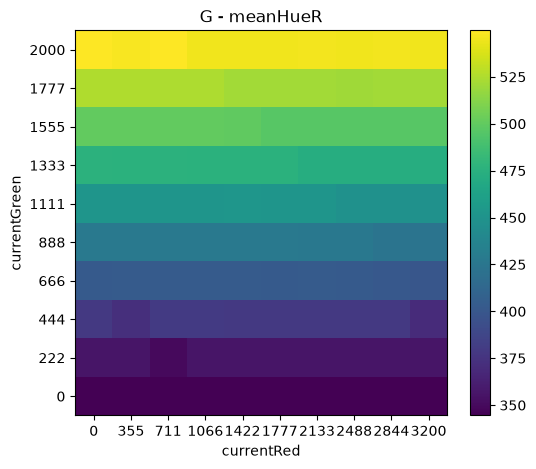

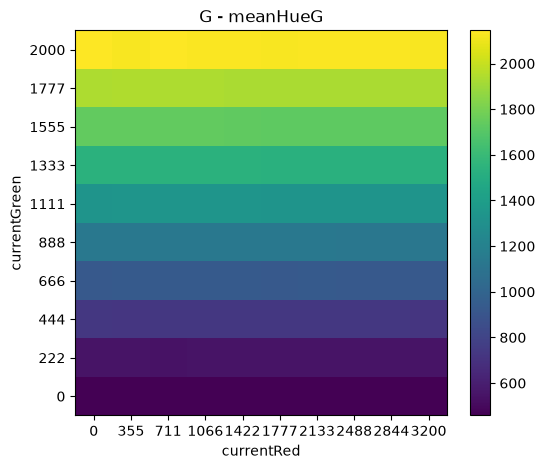

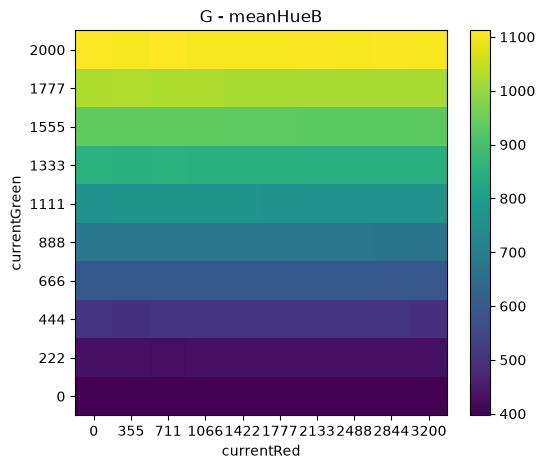

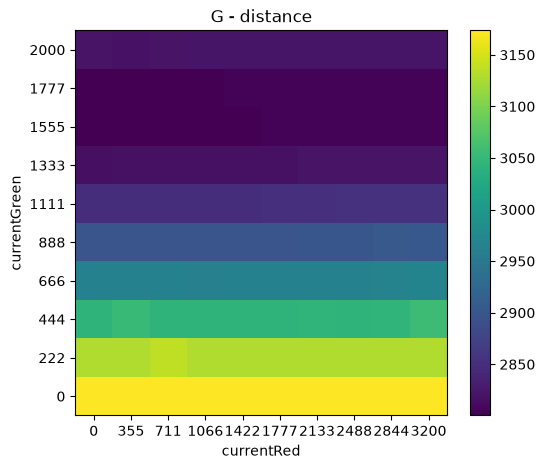

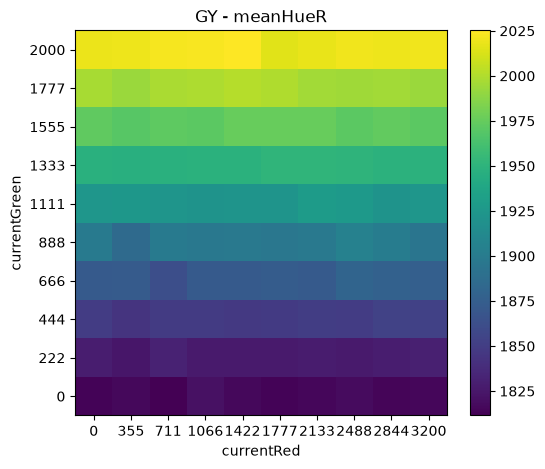

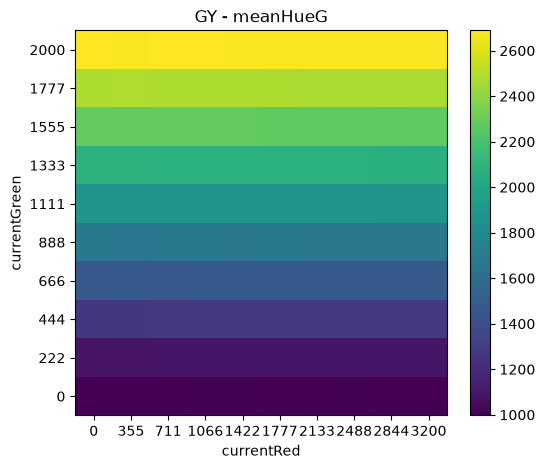

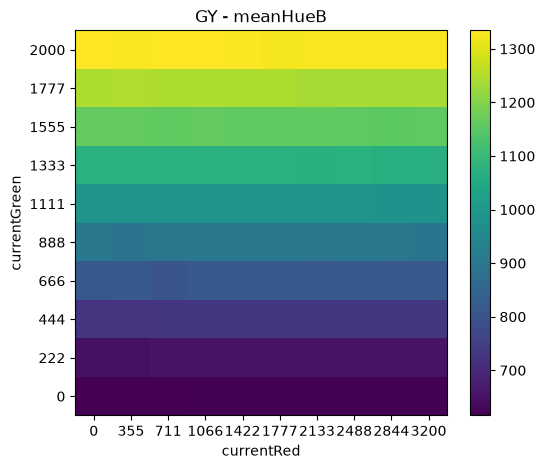

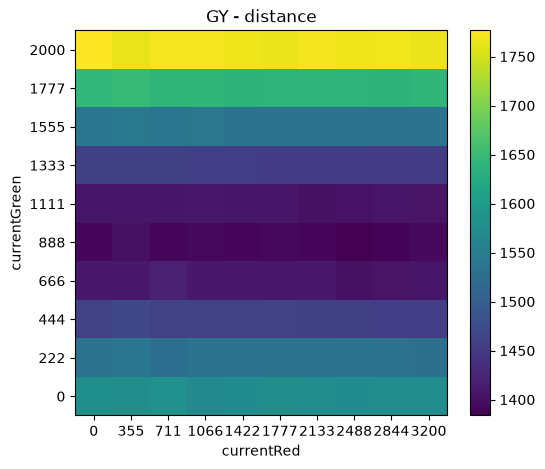

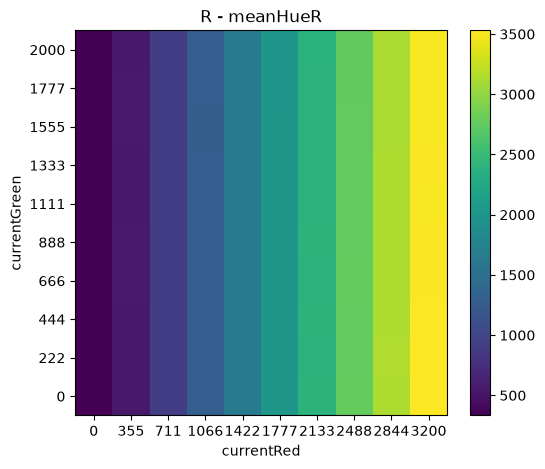

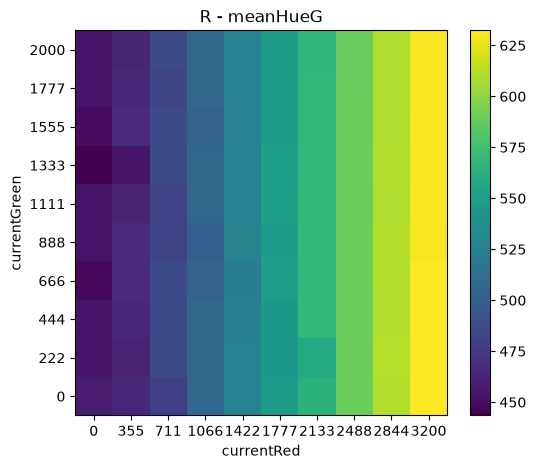

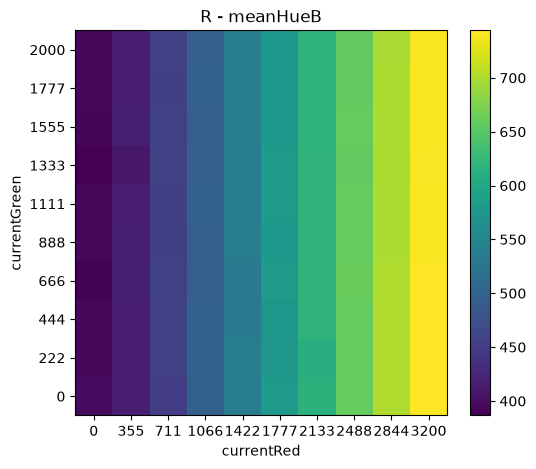

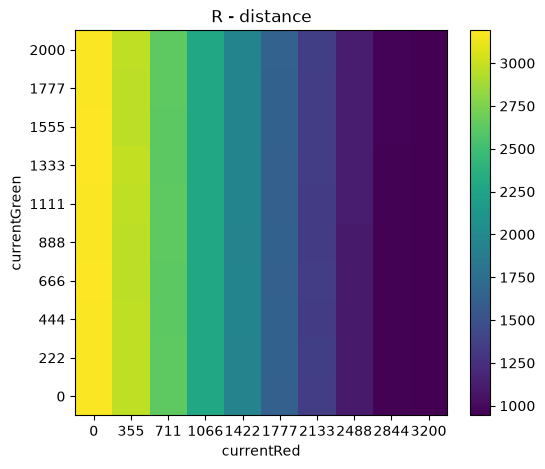

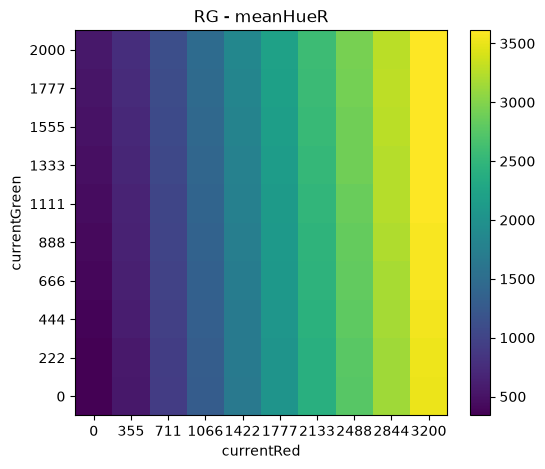

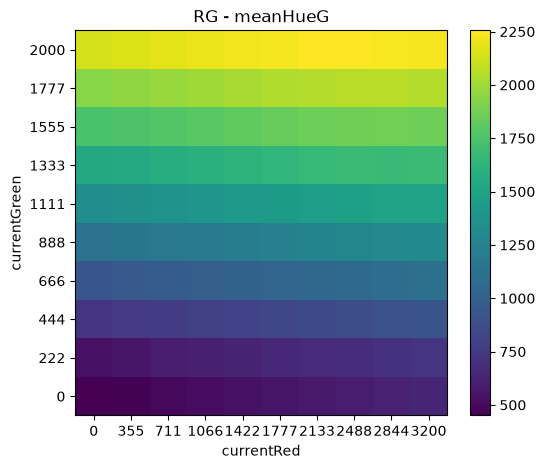

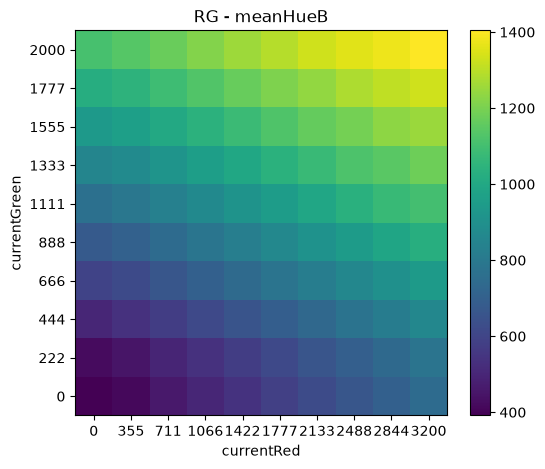

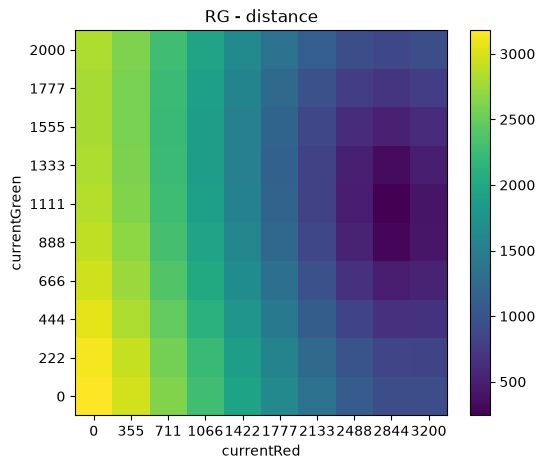

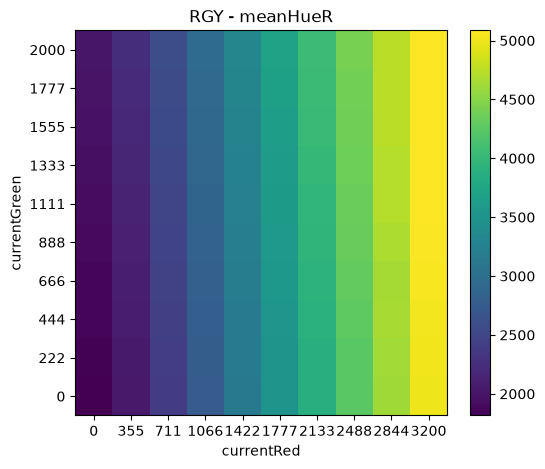

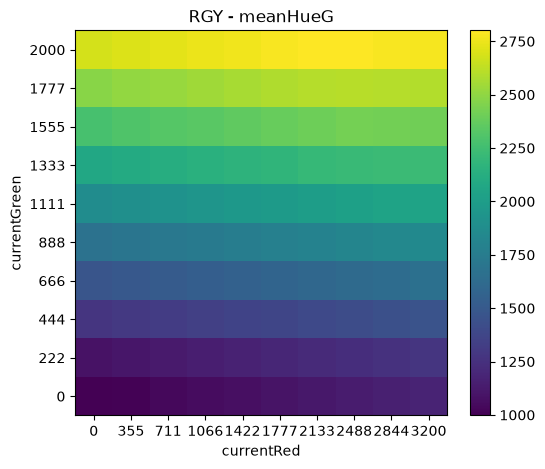

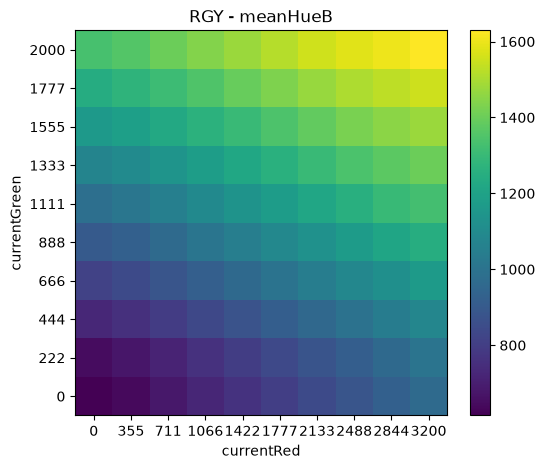

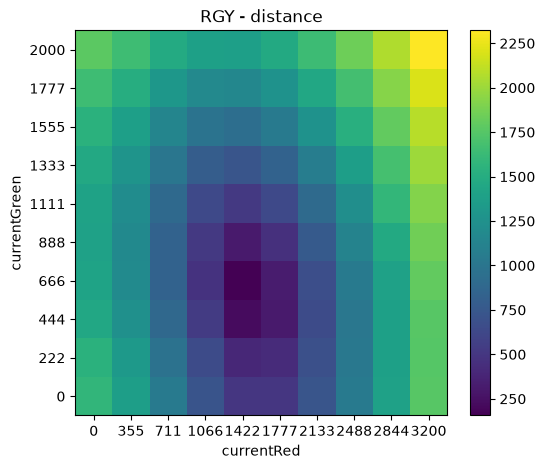

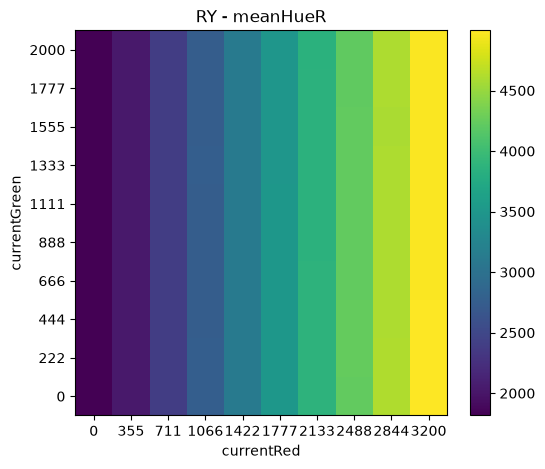

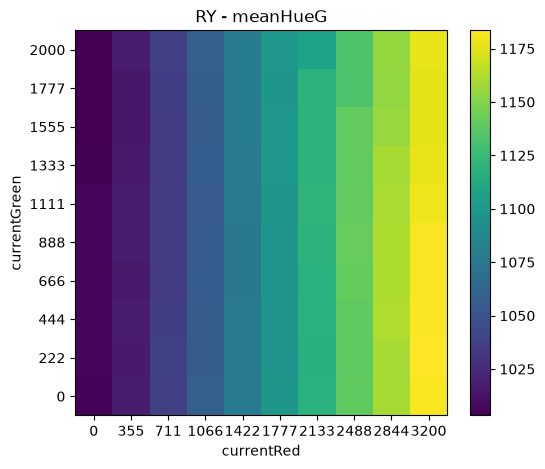

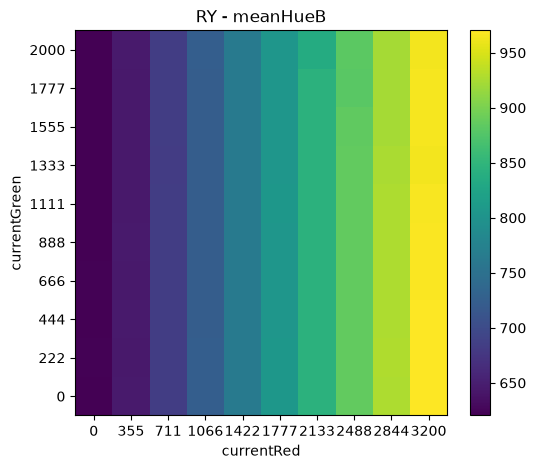

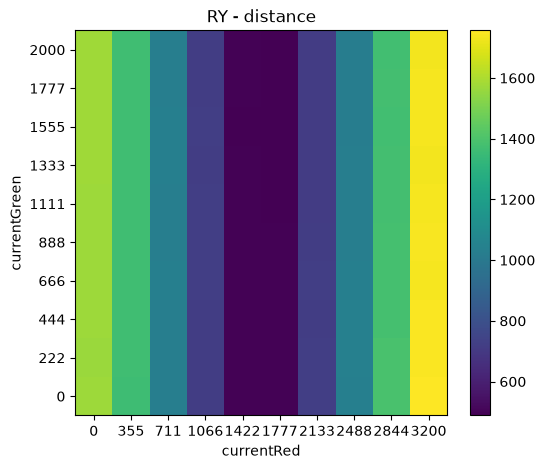

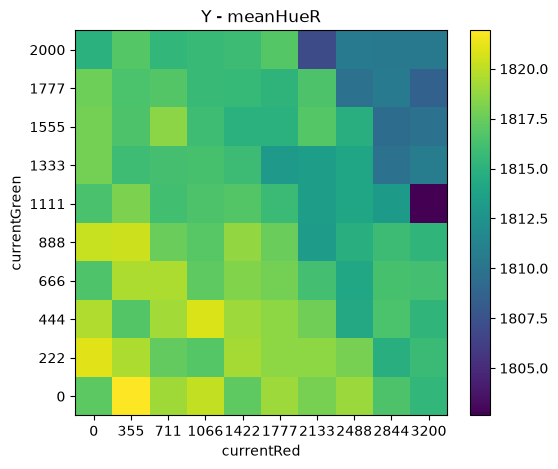

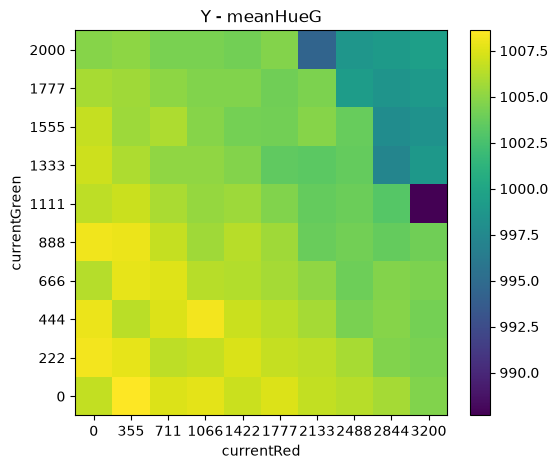

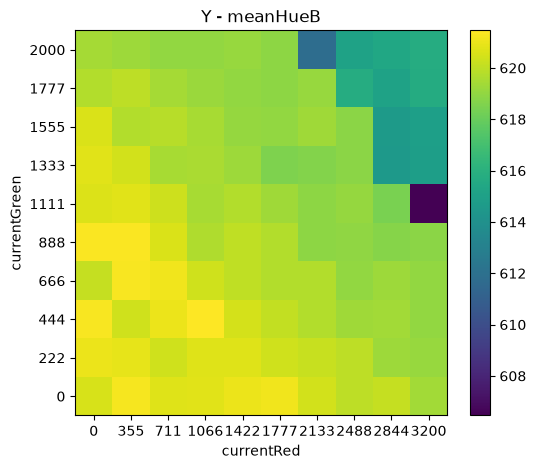

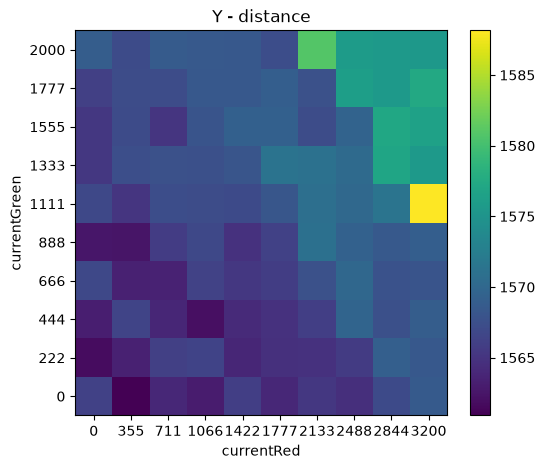

In [3]:
features = ["meanHueR", "meanHueG", "meanHueB", "distance"]

for condition, summary in sorted(summaries.items()):
    for feature in features:
        grid = compute_grid(summary, feature)
        ax = plot_grid_heatmap(grid)
        ax.set_title(f"{condition} - {feature}")
        plt.show()